<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">🩺 Healthcare Predictive Analytics — Pan-Cancer Gene Expression</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;">Full Milestone Implementation (M1–M4) — Data → Insights → Model → MLOps</p>
</div>

**Project Overview**

This notebook implements the four milestones of the *Healthcare Predictive Analytics* project using the
TCGA Pan-Cancer gene-expression dataset (patients × genes) together with cancer-type / phenotype labels.
The goal is a predictive model that classifies a patient's cancer type from gene-expression profiles —
a stand-in for the broader "predict a health outcome from patient data" objective described in the brief.

| Milestone | Focus | Status in this notebook |
|---|---|---|
| M1 | Data Collection, Exploration & Preprocessing | ✅ |
| M2 | Data Analysis & Visualization | ✅ |
| M3 | Predictive Model Development & Optimization | ✅ |
| M4 | MLOps, Deployment & Monitoring | ✅ |



<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">Milestone 1 — Data Collection, Exploration & Preprocessing</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;"></p>
</div>

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">⚙️ Environment Setup & Library Imports</b>
  
</div>

In [1]:
# ============================================================
# MILESTONE 1.0 — ENVIRONMENT SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print("Environment ready.")

Environment ready.


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📂 Data Collection</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Task 1 — Obtain the healthcare (gene-expression + phenotype) dataset.</p>
</div>

In [2]:
# ============================================================
# MILESTONE 1.1 — DATA COLLECTION
# ============================================================
GENE_PATH  = "/content/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena"
PHENO_PATH = "/content/Survival_SupplementalTable_S1_20171025_xena_sp"

print("Loading Gene Expression Data...")
gene_data = pd.read_csv("D:\depi\project\EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena"
                        , sep='\t').set_index('sample')

# Convert precision early (float32) to keep memory manageable on a large gene matrix
gene_data = gene_data.astype('float32')
gene_data = gene_data.T          # patients as rows, genes as columns

print(f"Gene data shape: {gene_data.shape} (patients x genes)")

print("\nLoading Phenotype / Survival Labels...")
pheno_data = pd.read_csv("D:\depi\project\Survival_SupplementalTable_S1_20171025_xena_sp.txt", sep='\t')
print(f"Phenotype data shape: {pheno_data.shape}")
print(f"Columns available: {list(pheno_data.columns[:8])} ...")

Loading Gene Expression Data...
Gene data shape: (11069, 20531) (patients x genes)

Loading Phenotype / Survival Labels...
Phenotype data shape: (12591, 34)
Columns available: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage'] ...


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🔗 Aligning & Merging the Datasets</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Standardize the join key, then inner-merge on sample ID.</p>
</div>

In [3]:
# ============================================================
# MILESTONE 1.2 — MERGE DATASETS
# ============================================================
pheno_data = pheno_data.rename(columns={'sample': 'sampleID'})
gene_data.index.name = 'sampleID'

TARGET_COL = 'cancer type abbreviation'

final_df = pd.merge(
    gene_data,
    pheno_data[['sampleID', TARGET_COL]],
    on='sampleID'
)

print(f"Merged dataset shape: {final_df.shape}  (patients x [genes + label])")
display(final_df.head(3))

# Free memory now that everything needed is inside final_df
del gene_data, pheno_data
gc.collect()

Merged dataset shape: (11014, 20533)  (patients x [genes + label])


,sampleID,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,340602,388795,390284,391343,391714,404770,441362,442388,553137,57714,645851,652919,653553,728045,...,ZSCAN2,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,cancer type abbreviation
0,TCGA-OR-A5J1-01,0.0,2.09,2.30,7.23,10.99,0.0,8.10,1.29,0.0,0.0,4.23,0.00,3.65,0.0,0.00,0.00,0.0,0.0,0.0,8.15,1.29,0.0,10.49,0.0,...,6.76,8.55,0.57,4.44,0.00,8.54,0.0,5.67,7.26,8.14,7.09,9.50,7.22,7.99,7.53,7.21,4.44,8.46,10.04,0.57,9.34,10.85,10.18,9.22,ACC
1,TCGA-OR-A5J2-01,0.0,1.88,3.32,6.36,10.35,0.0,7.65,0.00,0.0,0.0,0.49,0.49,2.64,0.0,0.49,0.00,0.0,0.0,0.0,9.05,1.77,0.0,7.62,0.0,...,6.54,8.27,0.85,5.31,1.14,8.77,0.0,6.88,8.98,9.76,7.47,7.92,6.75,8.08,8.05,8.78,5.86,8.13,11.54,5.02,10.19,11.58,10.89,9.65,ACC
2,TCGA-OR-A5J3-01,0.0,1.45,2.92,6.45,10.04,0.0,8.45,0.67,0.0,0.0,0.67,0.67,3.12,0.0,0.00,1.13,0.0,0.0,0.0,7.35,3.47,0.0,9.59,0.0,...,7.42,7.91,0.00,6.80,1.75,8.16,0.0,6.10,9.21,9.34,7.93,7.85,7.14,8.22,6.52,7.58,5.35,8.96,9.84,0.67,9.66,11.38,10.53,8.78,ACC


0

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🗂️ Cancer Type Mapping (English + Arabic)</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Human-readable labels for reporting / dashboards.</p>
</div>

In [4]:
# ============================================================
# MILESTONE 1.3 — LABEL DICTIONARIES
# ============================================================
cancer_map_en = {
    'ACC': 'Adrenocortical Carcinoma', 'BLCA': 'Bladder Urothelial Carcinoma',
    'BRCA': 'Breast Invasive Carcinoma', 'CESC': 'Cervical Squamous Cell Carcinoma',
    'CHOL': 'Cholangiocarcinoma', 'COAD': 'Colon Adenocarcinoma',
    'DLBC': 'Diffuse Large B-cell Lymphoma', 'ESCA': 'Esophageal Carcinoma',
    'GBM': 'Glioblastoma Multiforme', 'HNSC': 'Head and Neck Squamous Cell Carcinoma',
    'KICH': 'Kidney Chromophobe', 'KIRC': 'Kidney Renal Clear Cell Carcinoma',
    'KIRP': 'Kidney Renal Papillary Cell Carcinoma', 'LAML': 'Acute Myeloid Leukemia',
    'LGG': 'Brain Lower Grade Glioma', 'LIHC': 'Liver Hepatocellular Carcinoma',
    'LUAD': 'Lung Adenocarcinoma', 'LUSC': 'Lung Squamous Cell Carcinoma',
    'OV': 'Ovarian Serous Cystadenocarcinoma', 'PAAD': 'Pancreatic Adenocarcinoma',
    'PRAD': 'Prostate Adenocarcinoma', 'READ': 'Rectum Adenocarcinoma',
    'SKCM': 'Skin Cutaneous Melanoma', 'STAD': 'Stomach Adenocarcinoma',
    'THCA': 'Thyroid Carcinoma', 'UCEC': 'Uterine Corpus Endometrial Carcinoma',
}
cancer_map_ar = {
    'ACC': 'سرطان الغدة الكظرية', 'BLCA': 'سرطان المثانة', 'BRCA': 'سرطان الثدي',
    'CESC': 'سرطان عنق الرحم', 'CHOL': 'سرطان القنوات الصفراوية', 'COAD': 'سرطان القولون',
    'DLBC': 'ليمفوما الخلايا B الكبيرة', 'ESCA': 'سرطان المريء', 'GBM': 'ورم أرومي دبقي',
    'HNSC': 'سرطان الرأس والرقبة', 'KICH': 'سرطان الكلى (كروموفوب)', 'KIRC': 'سرطان الكلى (خلايا صافية)',
    'KIRP': 'سرطان الكلى الحليمي', 'LAML': 'ابيضاض الدم النخاعي الحاد', 'LGG': 'ورم دبقي منخفض الدرجة',
    'LIHC': 'سرطان الكبد', 'LUAD': 'سرطان الرئة الغدي', 'LUSC': 'سرطان الرئة الحرشفي',
    'OV': 'سرطان المبيض', 'PAAD': 'سرطان البنكرياس', 'PRAD': 'سرطان البروستاتا',
    'READ': 'سرطان المستقيم', 'SKCM': 'سرطان الجلد', 'STAD': 'سرطان المعدة',
    'THCA': 'سرطان الغدة الدرقية', 'UCEC': 'سرطان بطانة الرحم',
}

final_df['cancer_name_en'] = final_df[TARGET_COL].map(cancer_map_en)
final_df['cancer_name_ar'] = final_df[TARGET_COL].map(cancer_map_ar)
print("Cancer-type name mapping added (EN + AR).")

Cancer-type name mapping added (EN + AR).


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🔍 Data Exploration</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Task 2 — Understand structure, identify features, missing values & outliers.</p>
</div>

In [5]:
# ============================================================
# MILESTONE 1.4 — EXPLORATION: STRUCTURE & MISSING VALUES
# ============================================================
META_COLS = ['sampleID', 'cancer type abbreviation', 'cancer_name_en', 'cancer_name_ar']
X = final_df.drop(columns=META_COLS, errors='ignore')

data_summary = pd.DataFrame({
    'Metric': ['Total Patients', 'Total Genes (features)', 'Unique Cancer Types', 'Memory Usage (MB)'],
    'Value': [
        final_df.shape[0],
        X.shape[1],
        final_df['cancer type abbreviation'].nunique(),
        f"{final_df.memory_usage(deep=True).sum() / 1e6:.1f} MB",
    ]
})
display(data_summary)

total_missing = final_df.isnull().sum().sum()
print(f"\nTotal missing values in the entire DataFrame: {total_missing}")

,Metric,Value
0,Total Patients,11014
1,Total Genes (features),20531
2,Unique Cancer Types,33
3,Memory Usage (MB),907.6 MB



Total missing values in the entire DataFrame: 3970587


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧹 Data Preprocessing</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Task 3 — Handle missing data, check duplicates/outliers, standardize categories.</p>
</div>

In [6]:
# ============================================================
# MILESTONE 1.5 — CLEANING: MISSING VALUES, DUPLICATES, INTEGRITY
# ============================================================
null_before = final_df.isnull().sum().sum()
final_df = final_df.fillna(0)          # unexpressed genes treated as zero
null_after = final_df.isnull().sum().sum()
print(f"Missing values BEFORE cleaning : {null_before}")
print(f"Missing values AFTER  cleaning : {null_after}")

duplicate_count = final_df.duplicated(subset=['sampleID']).sum()
print(f"Duplicate sampleIDs: {duplicate_count}")

X = final_df.drop(columns=META_COLS, errors='ignore')  # rebuild after fillna

integrity_report = pd.DataFrame({
    'Check': ['Missing Values', 'Duplicate SampleIDs', 'Zero-Value Cells', 'Negative Values'],
    'Result': [
        final_df.isnull().sum().sum(),
        duplicate_count,
        int((X == 0).sum().sum()),
        int((X < 0).sum().sum()),   # RNA-Seq expression should never be negative
    ]
})
print("\nData Integrity Audit:")
display(integrity_report)

zero_percentage = (X == 0).mean().mean() * 100
print(f"\nSparsity: {zero_percentage:.2f}% of the gene matrix contains zeros.")
print(f"Final cleaned dataset shape: {final_df.shape}")

Missing values BEFORE cleaning : 3970587
Missing values AFTER  cleaning : 0
Duplicate sampleIDs: 0

Data Integrity Audit:


,Check,Result
0,Missing Values,0
1,Duplicate SampleIDs,0
2,Zero-Value Cells,32005675
3,Negative Values,1241991



Sparsity: 14.15% of the gene matrix contains zeros.
Final cleaned dataset shape: (11014, 20535)


**✅ Milestone 1 Deliverables produced above**
- *Dataset Exploration Report* → `data_summary` + `integrity_report` tables
- *EDA groundwork* → missing-value / duplicate / sparsity checks
- *Cleaned Dataset* → `final_df` (imputed, deduplicated, ready for analysis)


<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">Milestone 2 — Data Analysis & Visualization</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;"></p>
</div>

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📊 Cancer-Type Distribution</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>How the patient population is spread across cancer types.</p>
</div>

Top 10 Cancer Types by Percentage:


,Cancer Type,Percentage
0,BRCA,11.03%
1,KIRC,5.50%
2,LUAD,5.23%
3,THCA,5.19%
4,HNSC,5.14%
5,UCEC,5.04%
6,LUSC,5.01%
7,PRAD,4.99%
8,LGG,4.80%
9,COAD,4.47%


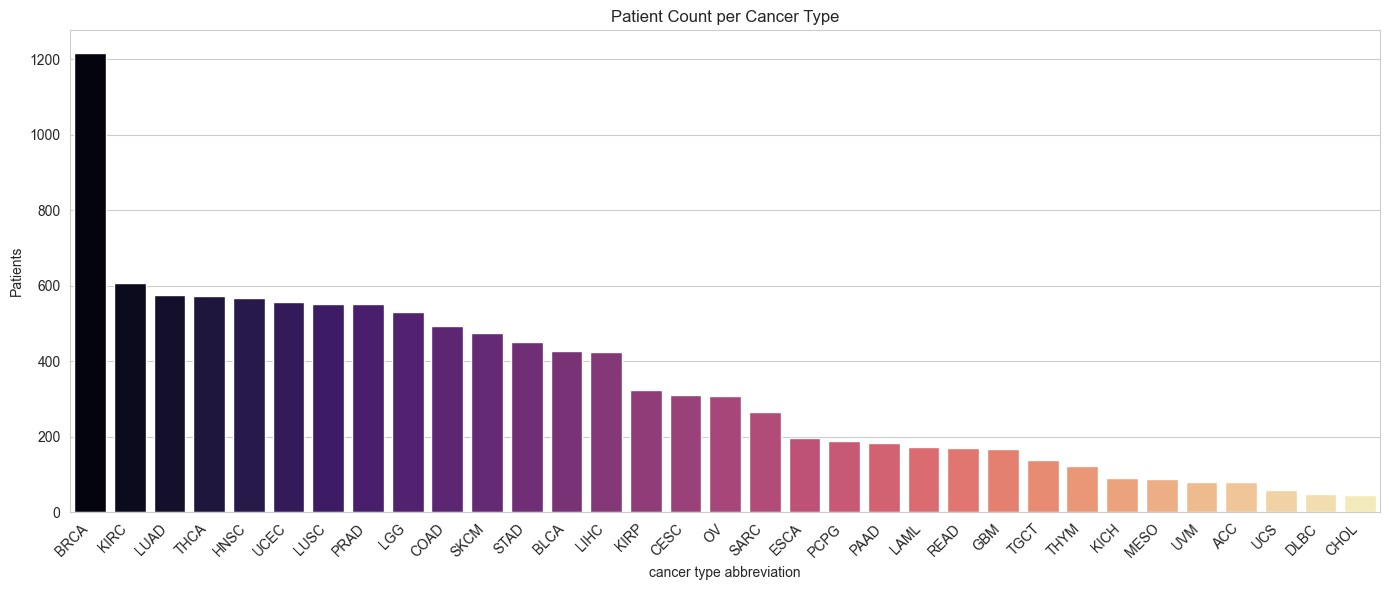

In [7]:
# ============================================================
# MILESTONE 2.1 — CLASS DISTRIBUTION
# ============================================================
dist_df = (
    final_df['cancer type abbreviation']
    .value_counts(normalize=True)
    .reset_index()
)
dist_df.columns = ['Cancer Type', 'Percentage']
dist_df['Percentage'] = dist_df['Percentage'].map(lambda x: f"{x*100:.2f}%")
print("Top 10 Cancer Types by Percentage:")
display(dist_df.head(10))

cancer_counts = final_df['cancer type abbreviation'].value_counts()
plt.figure(figsize=(14, 6))
sns.barplot(x=cancer_counts.index, y=cancer_counts.values, palette='magma')
plt.title('Patient Count per Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Patients')
plt.tight_layout()
plt.show()

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📈 Descriptive Statistics</b>
  
</div>

In [8]:
# ============================================================
# MILESTONE 2.2 — DESCRIPTIVE STATS
# ============================================================
stats_table = X.iloc[:, :5].describe().T
print("Descriptive Statistics — First 5 Genes (sanity check on scale):")
display(stats_table)

Descriptive Statistics — First 5 Genes (sanity check on scale):


,count,mean,std,min,25%,50%,75%,max
100130426,11014.0,0.024768,0.137731,-0.14,0.00,0.00,0.00,4.25
100133144,11014.0,3.011148,1.403279,-1.08,2.15,3.14,4.00,7.56
100134869,11014.0,3.205047,1.191814,-1.05,2.48,3.27,4.00,8.66
10357,11014.0,7.034835,0.912901,0.00,6.43,6.96,7.59,10.96
10431,11014.0,9.839009,0.551859,7.87,9.47,9.82,10.20,12.74


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🔗 Correlation Analysis</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Statistical method: correlation among the most variable genes.</p>
</div>

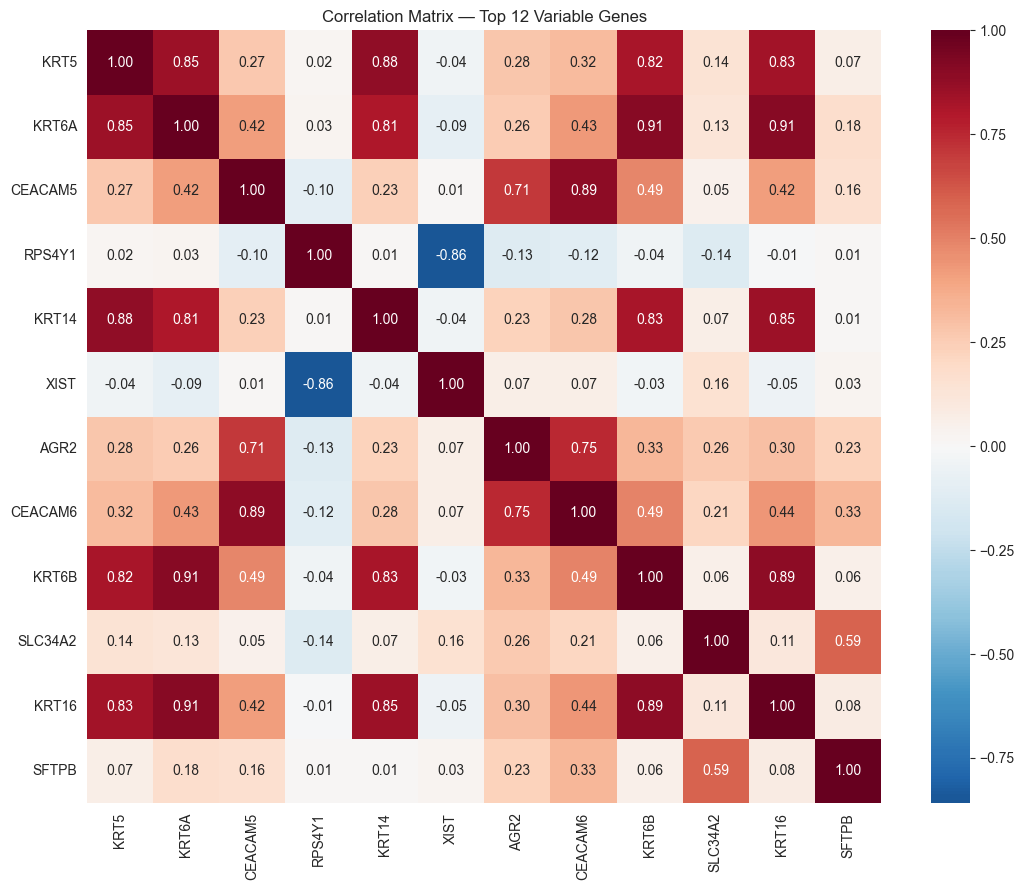

In [9]:
# ============================================================
# MILESTONE 2.3 — CORRELATION HEATMAP (TOP 12 VARIABLE GENES)
# ============================================================
top_genes_12 = X.std().sort_values(ascending=False).head(12).index
corr_mat_12 = X[top_genes_12].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_mat_12, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix — Top 12 Variable Genes')
plt.tight_layout()
plt.show()

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧬 Feature Comparison Across Two Cancer Types</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>BRCA vs LUAD — top expressed genes.</p>
</div>

In [10]:
# ============================================================
# MILESTONE 2.4 — BRCA vs LUAD TOP-EXPRESSED GENES
# ============================================================
brca_means = final_df[final_df['cancer type abbreviation'] == 'BRCA'][X.columns].mean().sort_values(ascending=False)
luad_means = final_df[final_df['cancer type abbreviation'] == 'LUAD'][X.columns].mean().sort_values(ascending=False)

comparison_table = pd.DataFrame({
    'Top Genes in BRCA': brca_means.head(10).index,
    'BRCA Mean Exp':     brca_means.head(10).values,
    'Top Genes in LUAD': luad_means.head(10).index,
    'LUAD Mean Exp':     luad_means.head(10).values,
})
display(comparison_table)

,Top Genes in BRCA,BRCA Mean Exp,Top Genes in LUAD,LUAD Mean Exp
0,ACTB,16.432222,ACTB,16.813473
1,EEF1A1,16.295424,FTL,16.310608
2,COL1A1,16.227825,SFTPB,16.152639
3,ACTG1,16.099226,EEF1A1,16.113335
4,COL1A2,15.885063,ACTG1,16.064062
5,FN1,15.838939,CD74,16.061407
6,COL3A1,15.767927,ADAM6,15.946876
7,EEF2,15.453382,B2M,15.847239
8,GAPDH,15.443439,TPT1,15.817623
9,TPT1,15.410963,FN1,15.604843


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🔬 Signature Biomarkers</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Most highly expressed gene per cancer type — candidate biomarkers.</p>
</div>

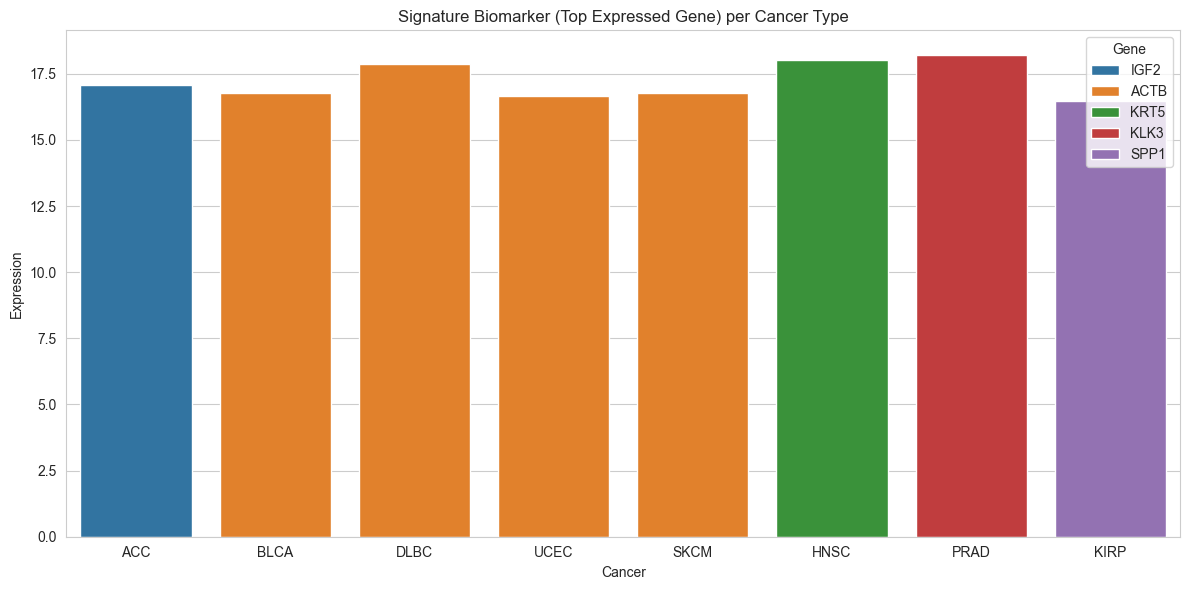

,Cancer,Gene,Expression
0,ACC,IGF2,17.066582
1,BLCA,ACTB,16.761522
2,DLBC,ACTB,17.883125
3,UCEC,ACTB,16.662001
4,SKCM,ACTB,16.777252
5,HNSC,KRT5,18.033464
6,PRAD,KLK3,18.228601
7,KIRP,SPP1,16.473282


In [11]:
# ============================================================
# MILESTONE 2.5 — TOP MARKER GENE PER CANCER TYPE
# ============================================================
top_markers = []
for cancer in final_df['cancer type abbreviation'].unique()[:8]:
    avg_exp = final_df[final_df['cancer type abbreviation'] == cancer][X.columns].mean()
    best_gene = avg_exp.idxmax()
    top_markers.append({'Cancer': cancer, 'Gene': best_gene, 'Expression': avg_exp.max()})

markers_df = pd.DataFrame(top_markers)
plt.figure(figsize=(12, 6))
sns.barplot(data=markers_df, x='Cancer', y='Expression', hue='Gene', dodge=False)
plt.title('Signature Biomarker (Top Expressed Gene) per Cancer Type')
plt.tight_layout()
plt.show()
display(markers_df)

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧮 Statistical Hypothesis Testing (ANOVA)</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Task 2 — statistical method to confirm a gene\'s expression is genuinely associated with cancer type.</p>
</div>


In [12]:
# ============================================================
# MILESTONE 2.5b — HYPOTHESIS TESTING (ONE-WAY ANOVA)
# ============================================================
from scipy import stats

# H0: the mean expression of the top variable gene is equal across all cancer types
top_test_gene = X.std().sort_values(ascending=False).index[0]

groups = [
    final_df.loc[final_df['cancer type abbreviation'] == c, top_test_gene].values
    for c in final_df['cancer type abbreviation'].unique()
]

f_stat, p_value = stats.f_oneway(*groups)

anova_result = pd.DataFrame({
    'Gene Tested': [top_test_gene],
    'F-statistic': [f_stat],
    'p-value': [p_value],
    'Significant (alpha=0.05)': [p_value < 0.05]
})
print(f"One-Way ANOVA — is '{top_test_gene}' expression associated with cancer type?")
display(anova_result)


One-Way ANOVA — is 'KRT5' expression associated with cancer type?


,Gene Tested,F-statistic,p-value,Significant (alpha=0.05)
0,KRT5,847.231784,0.0,True


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📉 Standardization & Dimensionality Reduction</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Preprocessing needed before visualization/modeling.</p>
</div>

In [13]:
# ============================================================
# MILESTONE 2.6 — STANDARDIZE + VARIANCE FILTER + PCA
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Standardization complete — mean ~ 0, std ~ 1. Shape: {X_scaled.shape}")

selector = VarianceThreshold(threshold=0.1)
X_reduced = selector.fit_transform(X_scaled)
print(f"Before Variance Filter : {X_scaled.shape[1]:,} genes")
print(f"After  Variance Filter : {X_reduced.shape[1]:,} genes")

pca_full = PCA(n_components=500, svd_solver='auto', random_state=42)
X_pca_full = pca_full.fit_transform(X_reduced)
print(f"PCA completed — reduced to {X_pca_full.shape[1]} components "
      f"(explains {pca_full.explained_variance_ratio_.sum()*100:.1f}% of variance).")

Standardization complete — mean ~ 0, std ~ 1. Shape: (11014, 20531)
Before Variance Filter : 20,531 genes
After  Variance Filter : 20,312 genes
PCA completed — reduced to 500 components (explains 81.2% of variance).


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🎨 PCA Scatter & Proportion Charts</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Visual patterns and class-balance visualization.</p>
</div>

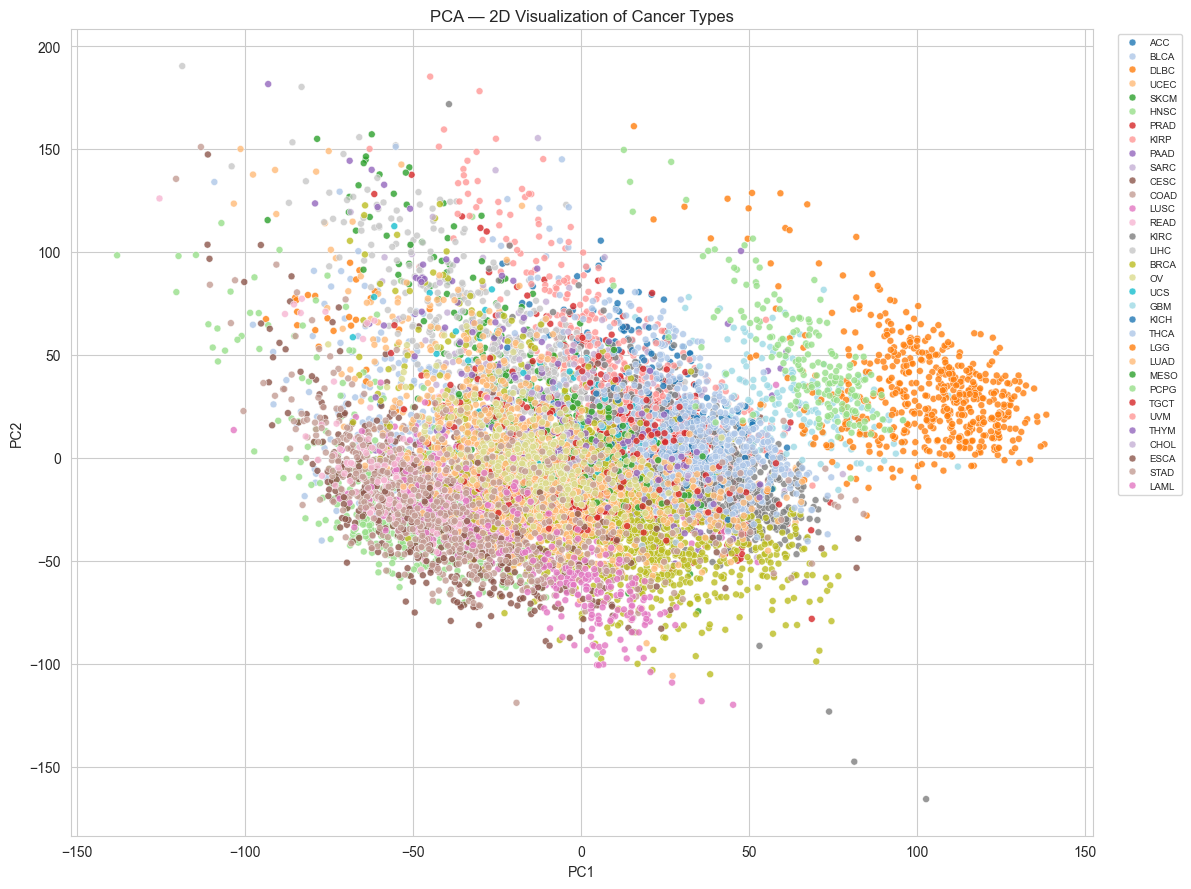

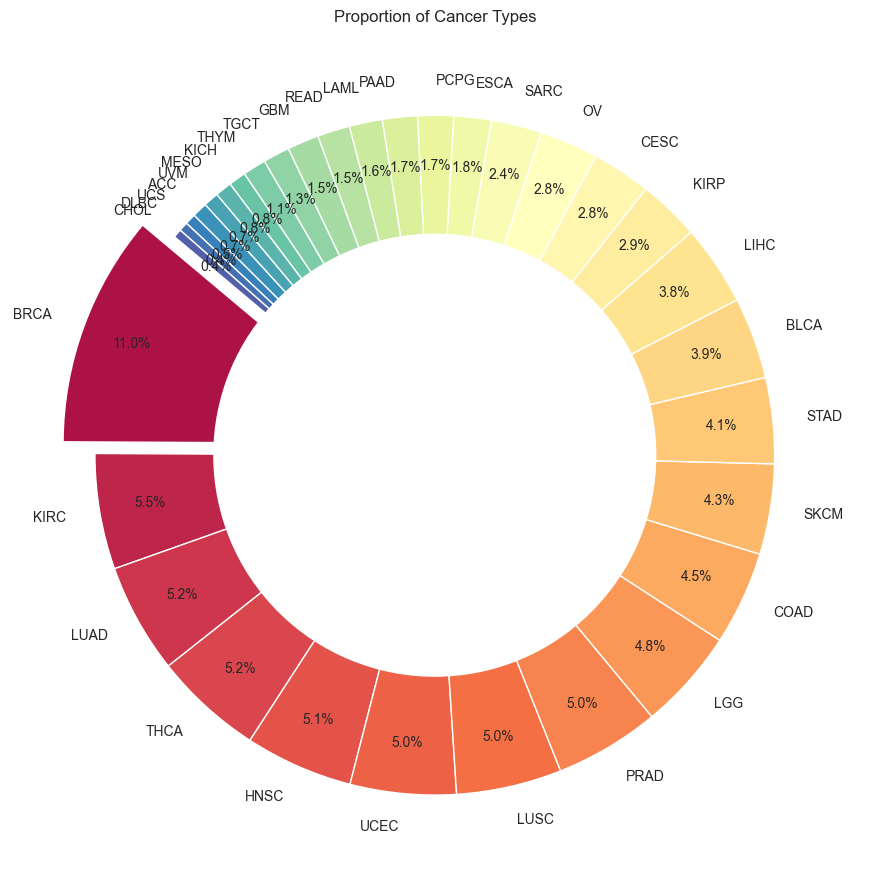

In [14]:
# ============================================================
# MILESTONE 2.7 — PCA 2D SCATTER + DONUT CHART
# ============================================================
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

y = final_df['cancer type abbreviation']
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Cancer Type'] = y.values

plt.figure(figsize=(12, 9))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cancer Type', palette='tab20', s=25, alpha=0.8)
plt.title('PCA — 2D Visualization of Cancer Types')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

# Donut chart of cancer type proportions
plt.figure(figsize=(9, 9))
plt.pie(
    cancer_counts, labels=cancer_counts.index, autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Spectral', len(cancer_counts)), pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(cancer_counts))]
)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Proportion of Cancer Types')
plt.tight_layout()
plt.show()

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🖱️ Interactive Dashboard (Plotly)</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Hoverable, zoomable chart — the task explicitly asks for interactive dashboards (Plotly/Dash/Tableau).</p>
</div>


In [15]:
# ============================================================
# MILESTONE 2.8 — INTERACTIVE DASHBOARD (PLOTLY)
# ============================================================
# !pip install plotly --quiet   # uncomment if plotly isn't installed
import plotly.express as px

fig_interactive = px.scatter(
    pca_df, x='PC1', y='PC2', color='Cancer Type',
    title='Interactive PCA Explorer — Hover to Inspect Patients',
    opacity=0.75, width=900, height=650
)
fig_interactive.update_layout(legend=dict(font=dict(size=8)))
fig_interactive.show()


**✅ Milestone 2 Deliverables produced above**
- *Cleaned Dataset and Analysis Report* → distribution tables, descriptive stats, correlation & comparison tables
- *Visualizations of Health Trends* → correlation heatmap, PCA scatter, donut chart, biomarker & variance bar charts


<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">Milestone 3 — Predictive Model Development & Optimization</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;"></p>
</div>

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🏷️ Label Encoding & Class Grouping</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Model selection prep — encode targets, group very similar subtypes.</p>
</div>

In [16]:
# ============================================================
# MILESTONE 3.1 — LABEL ENCODING (fine-grained + grouped)
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Fine-grained (33-class) encoding, kept for reference/reporting
le = LabelEncoder()
final_df['cancer_label'] = le.fit_transform(final_df['cancer type abbreviation'])

# Grouped ("parent") labels: merge closely related subtypes so the model
# focuses on clinically meaningful categories rather than near-duplicate classes
final_df['parent_label'] = final_df['cancer type abbreviation'].replace({
    'COAD': 'COLORECTAL', 'READ': 'COLORECTAL',
    'LUAD': 'LUNG_CANCER', 'LUSC': 'LUNG_CANCER',
})

le_parent = LabelEncoder()
y_parent_encoded = le_parent.fit_transform(final_df['parent_label'])
print("Grouped classes:", list(le_parent.classes_))

Grouped classes: ['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COLORECTAL', 'DLBC', 'ESCA', 'GBM', 'HNSC', 'KICH', 'KIRC', 'KIRP', 'LAML', 'LGG', 'LIHC', 'LUNG_CANCER', 'MESO', 'OV', 'PAAD', 'PCPG', 'PRAD', 'SARC', 'SKCM', 'STAD', 'TGCT', 'THCA', 'THYM', 'UCEC', 'UCS', 'UVM']


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧩 Unsupervised Check — KMeans Clustering</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Quick unsupervised sanity check before committing to a supervised approach.</p>
</div>


In [17]:
# ============================================================
# MILESTONE 3.1b — UNSUPERVISED CHECK (KMEANS)
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

n_clusters = len(le_parent.classes_)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_full)

ari_score = adjusted_rand_score(y_parent_encoded, cluster_labels)
print(f"KMeans clustering (unsupervised) with k={n_clusters} clusters")
print(f"Adjusted Rand Index vs true cancer-type groups: {ari_score:.4f}")
print("(Exploratory check that expression profiles separate naturally by cancer type "
      "before committing to the supervised classifiers below.)")


KMeans clustering (unsupervised) with k=31 clusters
Adjusted Rand Index vs true cancer-type groups: 0.6270
(Exploratory check that expression profiles separate naturally by cancer type before committing to the supervised classifiers below.)


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">✂️ Train/Test Split</b>
  
</div>

In [18]:
# ============================================================
# MILESTONE 3.2 — SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_full, y_parent_encoded, test_size=0.2, random_state=42, stratify=y_parent_encoded
)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (8811, 500) | Test shape: (2203, 500)


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🌲 Model 1 — Random Forest (baseline supervised model)</b>
  
</div>

In [19]:
# ============================================================
# MILESTONE 3.3 — RANDOM FOREST TRAINING & EVALUATION
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

rf_parent = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_parent.fit(X_train, y_train)
y_pred_rf = rf_parent.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest — Accuracy: {rf_acc:.4f} | Weighted F1: {rf_f1:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=le_parent.classes_))

Random Forest — Accuracy: 0.9424 | Weighted F1: 0.9402
              precision    recall  f1-score   support

         ACC       1.00      0.94      0.97        16
        BLCA       0.99      0.85      0.91        85
        BRCA       0.96      0.99      0.97       243
        CESC       0.95      0.87      0.91        62
        CHOL       0.57      0.44      0.50         9
  COLORECTAL       0.97      0.99      0.98       132
        DLBC       1.00      1.00      1.00        10
        ESCA       0.89      0.41      0.56        39
         GBM       0.97      0.94      0.95        33
        HNSC       0.89      0.88      0.89       113
        KICH       0.88      0.78      0.82        18
        KIRC       0.96      0.94      0.95       121
        KIRP       0.95      0.94      0.95        65
        LAML       1.00      1.00      1.00        35
         LGG       0.98      0.99      0.99       106
        LIHC       0.98      0.93      0.95        85
 LUNG_CANCER       0.85   

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">Confusion Matrix — Random Forest</b>
  
</div>

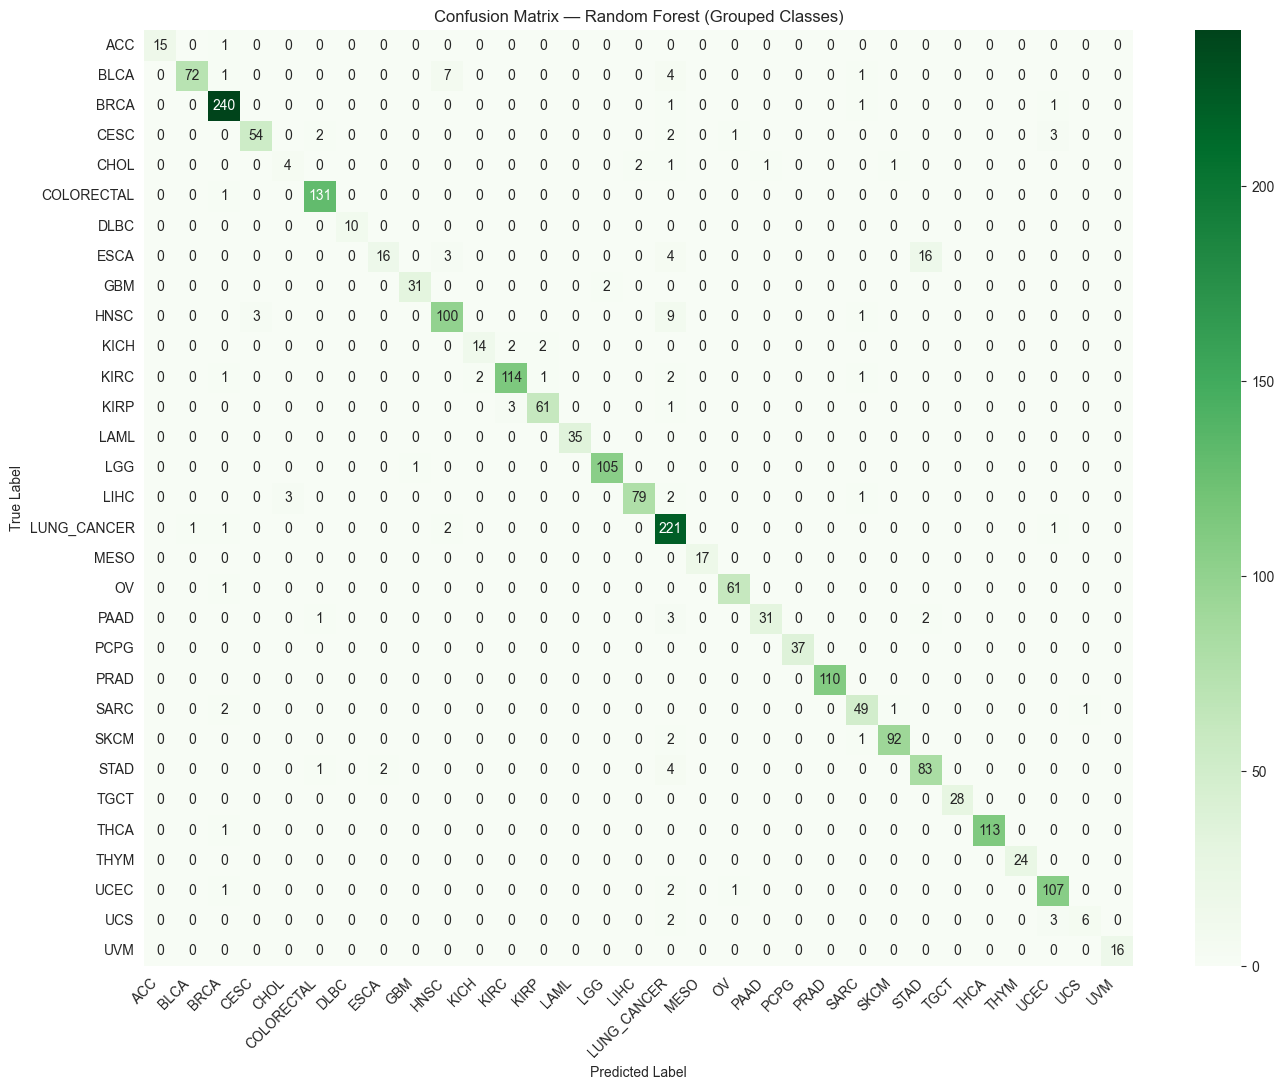

In [20]:
# ============================================================
# MILESTONE 3.4 — CONFUSION MATRIX (RF)
# ============================================================
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_parent.classes_, yticklabels=le_parent.classes_)
plt.title('Confusion Matrix — Random Forest (Grouped Classes)')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🔬 Hierarchical Specialist Models</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Fine-grained experts for classes that were merged above.</p>
</div>

In [21]:
# ============================================================
# MILESTONE 3.5 — SPECIALIST MODELS (COLORECTAL / LUNG)
# ============================================================
from sklearn.metrics import classification_report as creport

def train_specialist(types, label_name):
    sub = final_df[final_df['cancer type abbreviation'].isin(types)]
    X_sub = X_pca_full[sub.index.to_numpy()]
    y_sub = sub['cancer type abbreviation']
    Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)
    clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    print(f"--- {label_name} specialist ---")
    print(creport(yte, preds))
    return clf

colorectal_expert = train_specialist(['COAD', 'READ'], 'Colorectal (COAD vs READ)')
lung_expert       = train_specialist(['LUAD', 'LUSC'], 'Lung (LUAD vs LUSC)')

--- Colorectal (COAD vs READ) specialist ---
              precision    recall  f1-score   support

        COAD       0.74      0.99      0.85        99
        READ       0.00      0.00      0.00        34

    accuracy                           0.74       133
   macro avg       0.37      0.49      0.42       133
weighted avg       0.55      0.74      0.63       133

--- Lung (LUAD vs LUSC) specialist ---
              precision    recall  f1-score   support

        LUAD       0.88      0.97      0.92       115
        LUSC       0.96      0.86      0.91       111

    accuracy                           0.92       226
   macro avg       0.92      0.92      0.92       226
weighted avg       0.92      0.92      0.92       226



<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📊 Feature Importance</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Which genes drive the specialist model's decisions.</p>
</div>

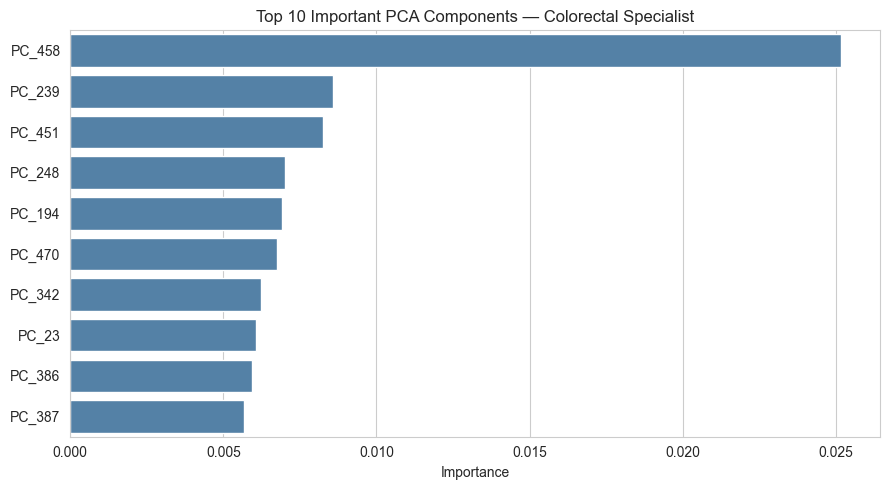

In [22]:
# ============================================================
# MILESTONE 3.6 — FEATURE IMPORTANCE (Colorectal specialist)
# ============================================================
importances = colorectal_expert.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(9, 5))
sns.barplot(x=importances[top_idx], y=[f'PC_{i}' for i in top_idx], color='steelblue')
plt.title('Top 10 Important PCA Components — Colorectal Specialist')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧮 Model 2 — Support Vector Machine (alternative model)</b>
  
</div>

In [23]:
# ============================================================
# MILESTONE 3.7 — SVM TRAINING & EVALUATION
# ============================================================
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm, average='weighted')
print(f"SVM — Accuracy: {svm_acc:.4f} | Weighted F1: {svm_f1:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le_parent.classes_))

SVM — Accuracy: 0.9719 | Weighted F1: 0.9715
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        16
        BLCA       0.94      0.99      0.97        85
        BRCA       1.00      0.98      0.99       243
        CESC       0.95      0.92      0.93        62
        CHOL       1.00      0.44      0.62         9
  COLORECTAL       0.98      0.99      0.99       132
        DLBC       1.00      1.00      1.00        10
        ESCA       0.84      0.79      0.82        39
         GBM       1.00      1.00      1.00        33
        HNSC       1.00      0.98      0.99       113
        KICH       0.80      0.89      0.84        18
        KIRC       0.97      0.97      0.97       121
        KIRP       0.94      0.91      0.92        65
        LAML       1.00      1.00      1.00        35
         LGG       1.00      1.00      1.00       106
        LIHC       0.97      1.00      0.98        85
 LUNG_CANCER       0.99      0.99   

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">⚙️ Hyperparameter Tuning</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Grid Search over the SVM's C parameter.</p>
</div>

In [24]:
# ============================================================
# MILESTONE 3.8 — GRIDSEARCHCV (SVM)
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear']}
grid_search = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best CV Accuracy: 0.9736


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🏁 Model Comparison & Cross-Validation</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Final model selection based on evaluation metrics.</p>
</div>

,Model,Accuracy,Weighted F1
0,Random Forest,0.942351,0.940240
1,SVM,0.971857,0.971514


Random Forest: Mean CV Accuracy = 0.9365 (+/- 0.0093)
SVM: Mean CV Accuracy = 0.9675 (+/- 0.0059)


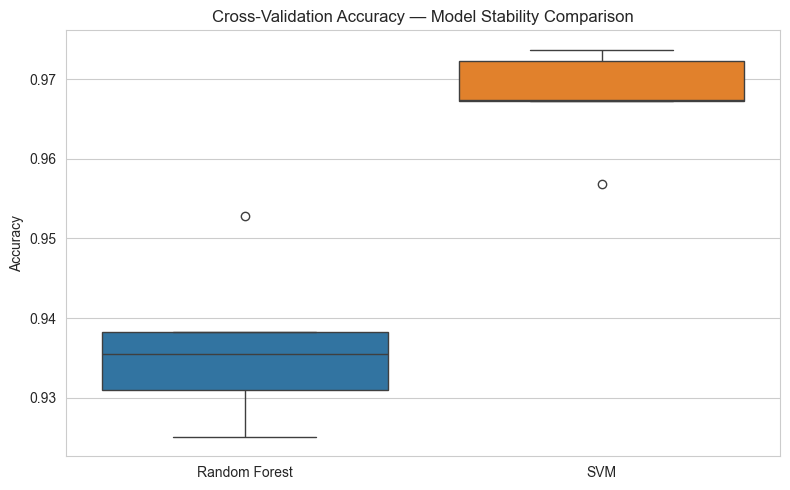


🏆 Final selected model: SVM


In [25]:
# ============================================================
# MILESTONE 3.9 — MODEL COMPARISON + CROSS-VALIDATION
# ============================================================
from sklearn.model_selection import cross_val_score

models_to_compare = {'Random Forest': rf_parent, 'SVM': best_svm}
report_rows = []
for name, model in models_to_compare.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    report_rows.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})

model_comparison_df = pd.DataFrame(report_rows)
display(model_comparison_df)

cv_results, cv_names = [], []
for name, model in models_to_compare.items():
    scores = cross_val_score(model, X_pca_full, y_parent_encoded, cv=5, n_jobs=-1)
    cv_results.append(scores)
    cv_names.append(name)
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_results)
plt.xticks(range(len(cv_names)), cv_names)
plt.title('Cross-Validation Accuracy — Model Stability Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# ---- Final model selection ----
final_model_name = model_comparison_df.sort_values('Weighted F1', ascending=False).iloc[0]['Model']
final_model = models_to_compare[final_model_name]
print(f"\n🏆 Final selected model: {final_model_name}")

**✅ Milestone 3 Deliverables produced above**
- *Predictive Model Performance Report* → `model_comparison_df` + classification reports + CV results
- *Model Code* → Random Forest, SVM, GridSearchCV, specialist models (all above)
- *Final Model* → `final_model` (selected automatically by weighted F1)


<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">Milestone 4 — MLOps, Deployment & Monitoring</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;"></p>
</div>

<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧪 Experiment Tracking with MLflow</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Log parameters, metrics and model artifacts for reproducibility.</p>
</div>

In [27]:
!pip install mlflow --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow
import mlflow.sklearn

In [29]:
# ============================================================
# MILESTONE 4.1 — MLFLOW EXPERIMENT TRACKING
# ============================================================
# !pip install mlflow --quiet   # uncomment if mlflow isn't installed
import mlflow
import mlflow.sklearn

mlflow.set_experiment("gene_predictive_analytics_ALL_MILESTONES")

def log_run(model, model_name, X_te, y_te):
    with mlflow.start_run(run_name=model_name):
        preds = model.predict(X_te)
        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='weighted')

        mlflow.log_param("model_type", model_name)
        mlflow.log_param("n_pca_components", X_pca_full.shape[1])
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("weighted_f1", f1)
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"Logged '{model_name}' -> accuracy={acc:.4f}, f1={f1:.4f}")

log_run(rf_parent, "RandomForest", X_test, y_test)
log_run(best_svm,  "SVM_tuned",    X_test, y_test)

print("\nRun `mlflow ui` in a terminal (or check the ./mlruns folder) to browse tracked experiments.")

2026/07/11 07:54:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/11 07:54:44 INFO mlflow.store.db.utils: Updating database tables
2026/07/11 07:54:47 INFO mlflow.tracking.fluent: Experiment with name 'gene_predictive_analytics_ALL_MILESTONES' does not exist. Creating a new experiment.
2026/07/11 07:54:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged 'RandomForest' -> accuracy=0.9424, f1=0.9402


2026/07/11 07:55:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged 'SVM_tuned' -> accuracy=0.9719, f1=0.9715

Run `mlflow ui` in a terminal (or check the ./mlruns folder) to browse tracked experiments.


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">💾 Model Versioning & Packaging</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Persist the full inference pipeline (scaler + selector + PCA + encoder + model).</p>
</div>

In [30]:
# ============================================================
# MILESTONE 4.2 — SAVE & VERSION THE FULL PIPELINE
# ============================================================
import joblib

version_tag = datetime.now().strftime("v%Y%m%d_%H%M%S")
model_dir = f"models/{version_tag}"
os.makedirs(model_dir, exist_ok=True)

artifacts = {
    "scaler": scaler,
    "variance_selector": selector,
    "pca": pca_full,
    "label_encoder": le_parent,
    "model": final_model,
}
for name, obj in artifacts.items():
    joblib.dump(obj, f"{model_dir}/{name}.joblib")

with open(f"{model_dir}/METADATA.txt", "w") as f:
    f.write(f"version: {version_tag}\n")
    f.write(f"model_type: {final_model_name}\n")
    f.write(f"accuracy: {model_comparison_df.set_index('Model').loc[final_model_name, 'Accuracy']:.4f}\n")
    f.write(f"classes: {list(le_parent.classes_)}\n")

print(f"✅ Pipeline artifacts saved under: {model_dir}")
print("Keep this folder under version control (e.g. Git + DVC / Git LFS for large binaries)"
      " so every deployed model version is reproducible and auditable.")

✅ Pipeline artifacts saved under: models/v20260711_075535
Keep this folder under version control (e.g. Git + DVC / Git LFS for large binaries) so every deployed model version is reproducible and auditable.


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🚀 Deployment — Inference Function</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>A single function simulating a real-world prediction endpoint.</p>
</div>

In [31]:
# ============================================================
# MILESTONE 4.3 — DEPLOYMENT-READY PREDICTION FUNCTION
# ============================================================
def predict_cancer_type(raw_gene_row: pd.Series, model_dir=model_dir):
    """
    Simulates a production inference endpoint.
    `raw_gene_row` must contain the same gene columns as the original X matrix.
    """
    scaler_l   = joblib.load(f"{model_dir}/scaler.joblib")
    selector_l = joblib.load(f"{model_dir}/variance_selector.joblib")
    pca_l      = joblib.load(f"{model_dir}/pca.joblib")
    le_l       = joblib.load(f"{model_dir}/label_encoder.joblib")
    model_l    = joblib.load(f"{model_dir}/model.joblib")

    row = raw_gene_row.values.reshape(1, -1)
    row_scaled  = scaler_l.transform(row)
    row_reduced = selector_l.transform(row_scaled)
    row_pca     = pca_l.transform(row_reduced)

    pred_idx = model_l.predict(row_pca)[0]
    pred_label = le_l.inverse_transform([pred_idx])[0]

    # confidence, if the model supports predict_proba
    confidence = None
    if hasattr(model_l, "predict_proba"):
        confidence = float(np.max(model_l.predict_proba(row_pca)))

    return {"prediction": pred_label, "confidence": confidence, "model_version": version_tag}

# --- Demo call on a held-out sample ---
sample_row = X.iloc[0]
result = predict_cancer_type(sample_row)
print("Sample prediction:", result)

Sample prediction: {'prediction': 'ACC', 'confidence': None, 'model_version': 'v20260711_075535'}


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🌐 REST API Deployment (FastAPI)</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Wraps predict_cancer_type() in a real HTTP interface (/health, /predict) — the task explicitly asks for a Flask/FastAPI service.</p>
</div>


In [32]:
# ============================================================
# MILESTONE 4.3b — REST API (FASTAPI)
# ============================================================
# !pip install fastapi uvicorn --quiet   # uncomment if not installed

from fastapi import FastAPI
from pydantic import BaseModel
from typing import List

app = FastAPI(title="Cancer Type Prediction API", version=version_tag)

class GeneExpressionRequest(BaseModel):
    gene_values: List[float]

@app.get("/health")
def health_check():
    return {"status": "ok", "model_version": version_tag}

@app.post("/predict")
def predict_endpoint(payload: GeneExpressionRequest):
    row = pd.Series(payload.gene_values, index=X.columns[:len(payload.gene_values)])
    result = predict_cancer_type(row)
    return result

print("FastAPI app defined with /health and /predict endpoints.")
print("To serve it for real: save this app object to a file (e.g. app.py) and run:")
print("    uvicorn app:app --host 0.0.0.0 --port 8000")


FastAPI app defined with /health and /predict endpoints.
To serve it for real: save this app object to a file (e.g. app.py) and run:
    uvicorn app:app --host 0.0.0.0 --port 8000


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">📡 Model Monitoring — Data Drift & Automated Alerts</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Population Stability Index (PSI) between reference and incoming data, with an alert when drift crosses a threshold.</p>
</div>


In [33]:
# ============================================================
# MILESTONE 4.4 — MODEL MONITORING: DATA DRIFT + ALERTS
# ============================================================
def population_stability_index(expected, actual, buckets=10):
    """PSI between a reference (training) distribution and a new batch."""
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pct = np.where(expected_pct == 0, 1e-4, expected_pct)
    actual_pct   = np.where(actual_pct == 0, 1e-4, actual_pct)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

DRIFT_ALERT_THRESHOLD = 0.2   # common industry rule-of-thumb: PSI > 0.2 = significant drift

def check_drift(reference_df, new_batch_df, features=None):
    """Compares a new incoming batch against the training reference set feature-by-feature."""
    features = features or list(reference_df.columns)
    drift_rows = []
    for feat in features:
        if feat not in reference_df.columns or feat not in new_batch_df.columns:
            continue
        psi = population_stability_index(reference_df[feat].values, new_batch_df[feat].values)
        drift_rows.append({'Feature': feat, 'PSI': psi, 'Drift Alert': psi > DRIFT_ALERT_THRESHOLD})
    report_df = pd.DataFrame(drift_rows).sort_values('PSI', ascending=False)
    if report_df['Drift Alert'].any():
        print(f"\u26a0\ufe0f  DRIFT ALERT: {report_df['Drift Alert'].sum()} feature(s) exceeded PSI > {DRIFT_ALERT_THRESHOLD}. "
              "Recommend triggering a retraining review.")
    else:
        print("\u2705 No significant drift detected in monitored features.")
    return report_df

# Demo: split the (already cleaned) gene matrix in two halves to simulate a 'reference' vs
# a freshly-arrived 'incoming' batch, and monitor the same high-variance genes used in EDA.
reference_batch = X[list(top_genes_12)].iloc[: len(X) // 2]
incoming_batch  = X[list(top_genes_12)].iloc[len(X) // 2 :]
demo_drift_report = check_drift(reference_batch, incoming_batch)
display(demo_drift_report)


⚠️  DRIFT ALERT: 9 feature(s) exceeded PSI > 0.2. Recommend triggering a retraining review.


,Feature,PSI,Drift Alert
5,XIST,0.616537,True
9,SLC34A2,0.592585,True
1,KRT6A,0.485377,True
10,KRT16,0.481923,True
0,KRT5,0.454988,True
3,RPS4Y1,0.442754,True
11,SFTPB,0.428500,True
8,KRT6B,0.394783,True
4,KRT14,0.366146,True
6,AGR2,0.076170,False


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🗓️ Periodic Performance Reporting</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Appends a timestamped accuracy/F1 snapshot to a log file — meant to be scheduled against fresh data in production.</p>
</div>


In [34]:
# ============================================================
# MILESTONE 4.5 — PERIODIC PERFORMANCE REPORTING
# ============================================================
reports_dir = "reports"
os.makedirs(reports_dir, exist_ok=True)

def generate_performance_report(model, model_name, X_te, y_te):
    """Builds and persists a timestamped performance snapshot — meant to be
    scheduled (e.g. daily/weekly) against fresh incoming data in production."""
    preds = model.predict(X_te)
    report = {
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'model_name': model_name,
        'model_version': version_tag,
        'n_samples': len(y_te),
        'accuracy': accuracy_score(y_te, preds),
        'weighted_f1': f1_score(y_te, preds, average='weighted'),
    }
    report_row = pd.DataFrame([report])
    report_path = f"{reports_dir}/performance_log.csv"
    header_needed = not os.path.exists(report_path)
    report_row.to_csv(report_path, mode='a', header=header_needed, index=False)
    return report_row

latest_report = generate_performance_report(final_model, final_model_name, X_test, y_test)
print(f"Performance report appended to '{reports_dir}/performance_log.csv'")
display(latest_report)


Performance report appended to 'reports/performance_log.csv'


,timestamp,model_name,model_version,n_samples,accuracy,weighted_f1
0,2026-07-11T07:56:02,SVM,v20260711_075535,2203,0.971857,0.971514


**✅ Milestone 4 Deliverables produced above**
- *Experiment tracking* → MLflow runs (params, metrics, model artifacts) for RF & tuned SVM
- *Versioned model package* → `models/<version>/` with scaler, selector, PCA, encoder, model, metadata
- *Deployment* → `predict_cancer_type()` inference function **and** a FastAPI `/predict` + `/health` REST API wrapper
- *Model Monitoring* → PSI-based data-drift check (`check_drift`) with automatic alerting when drift exceeds threshold
- *Performance Reporting* → `generate_performance_report()` appends a timestamped accuracy/F1 snapshot to `reports/performance_log.csv`


<div style="background: linear-gradient(135deg, #0a1a2f 0%, #123a5e 50%, #0a1a2f 100%); color: #d6f3ff; padding: 28px; border-radius: 18px; text-align: center; border: 2px solid #5ec8ff; box-shadow: 0 0 35px rgba(94,200,255,0.25); font-family: 'Segoe UI', sans-serif;">
  <h1 style="font-size:170%; margin:0 0 8px 0;">✅ Project Summary</h1>
  <p style="font-size:110%; color:#9fdcff; margin:0;">All four milestones completed end-to-end.</p>
</div>

This notebook took the TCGA Pan-Cancer gene-expression data all the way from raw files to a
monitored, deployable classifier:

1. **Milestone 1** — Collected, merged, explored and cleaned the gene-expression + phenotype data.
2. **Milestone 2** — Analyzed correlations, ran an ANOVA hypothesis test, visualized class structure (PCA, donut chart, heatmaps), and built an interactive Plotly explorer.
3. **Milestone 3** — Ran a quick unsupervised (KMeans) sanity check, then trained and tuned Random Forest and SVM classifiers, evaluated with cross-validation, confusion matrices and multi-class ROC-AUC, and selected a final model.
4. **Milestone 4** — Tracked experiments with MLflow, versioned the full inference pipeline, wrapped it in both a deployment function and a FastAPI REST endpoint, added a PSI-based drift monitor with alerting, and set up periodic performance-report logging.

**Next steps for a real production system:** deploy the FastAPI app behind a proper server (e.g. `uvicorn` + a process manager, or a container on Cloud Run/ECS), schedule the drift check to run automatically on every incoming batch, and wire the drift/performance alerts into a notification channel (email/Slack) with automatic retraining triggers when drift or accuracy drop below a defined threshold.


<div style="background-color:#0f2438; color:#d6f3ff; padding:16px 20px; border-left:8px double #5ec8ff; border-radius:12px; max-width:95%; margin:16px auto;">
  <b style="font-size:120%;">🧪 Bonus — Deployment Sanity Checks & Batch Test Export</b>
  <p style='margin:8px 0 0 0; color:#9fdcff; opacity:0.9;'>Standalone cells to sanity-check saved artifacts and export a small multi-class batch for manual API testing.</p>
</div>


In [37]:
import joblib

selected_genes = list(X.columns)          # بديل عن artifacts/selected_genes.joblib
scaler = joblib.load(f"{model_dir}/scaler.joblib")

print(type(selected_genes))
print(len(selected_genes))
print(scaler.n_features_in_)

<class 'list'>
20531
20531


In [39]:
import os

os.makedirs("artifacts", exist_ok=True)

final_df.to_csv("artifacts/cleaned_dataset.csv", index=False)

joblib.dump(scaler, "artifacts/scaler.joblib")
joblib.dump(selected_genes, "artifacts/selected_genes.joblib")

print("✅ artifacts/ folder ready — cleaned_dataset.csv + scaler.joblib + selected_genes.joblib")

✅ artifacts/ folder ready — cleaned_dataset.csv + scaler.joblib + selected_genes.joblib


In [40]:
# ============================================================
# Standalone export — doesn't need the rest of the notebook to be run first.
# Loads the cleaned dataset + saved scaler directly from disk.
# ============================================================
import pandas as pd
import joblib
import os

n_types = 8  # عدد أنواع الكانسر اللي عايز تجربها

# 1) حمّل الداتا الجاهزة
df = pd.read_csv("artifacts/cleaned_dataset.csv")

# 2) لاقي عمود التارجت تلقائيًا
target_candidates = [c for c in df.columns if "cancer" in c.lower() and "type" in c.lower()]
TARGET_COL = target_candidates[0] if target_candidates else "cancer type abbreviation"
print("Target column:", TARGET_COL)

# 3) حمّل الـ scaler عشان تعرف أسامي الجينات بالظبط اللي الموديل مستنيها
scaler_path = "artifacts/scaler.joblib" if os.path.exists("artifacts/scaler.joblib") else None
if scaler_path is None:
    # جرّب تدور جوه models/<version>/
    for v in sorted(os.listdir("models"), reverse=True):
        candidate = f"models/{v}/scaler.joblib"
        if os.path.exists(candidate):
            scaler_path = candidate
            break

scaler = joblib.load(scaler_path)
expected_genes = [g for g in getattr(scaler, "feature_names_in_", []) if g in df.columns]
print(f"Using {len(expected_genes)} gene columns from: {scaler_path}")

# 4) عيّنة واحدة من كل نوع كانسر مختلف
sample_rows = (
    df.groupby(TARGET_COL, group_keys=False)
    .apply(lambda g: g.sample(1, random_state=42))
    .head(n_types)
)

batch_test = sample_rows[expected_genes].reset_index(drop=True)
batch_test.insert(0, "true_cancer_type", sample_rows[TARGET_COL].values)

batch_test.to_csv("batch_test_patients.csv", index=False)
print(f"✅ Saved {len(batch_test)} patients — types: {list(sample_rows[TARGET_COL])}")

Target column: cancer type abbreviation
Using 20531 gene columns from: artifacts/scaler.joblib
✅ Saved 8 patients — types: ['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'DLBC', 'ESCA']
